# Entropy Dynamics and Correlation

Goal: analyze entropy loss trends and relate them to performance.

Expected takeaway: identify whether lower/higher entropy aligns with better pass@k.


In [53]:
import math
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

DATA_DIR_CANDIDATES = [
    Path.cwd() / "final_results" / "data",
    Path.cwd().parent / "final_results" / "data",
    Path.cwd() / "data",
    Path.cwd().parents[1] / "final_results" / "data",
    Path(__file__).resolve().parents[1] / "data" if '__file__' in globals() else Path.cwd() / "final_results" / "data",
]

# Robust data path resolver (works when running from repo root or final_results/tools)

# Robust data path resolver (works when running from repo root or final_results/tools)

def resolve_data_path(filename: str) -> Path:
    cwd = Path.cwd().resolve()
    candidates = [
        cwd / "final_results" / "data" / filename,
        cwd / "data" / filename,
    ]
    for parent in [cwd] + list(cwd.parents):
        candidates.append(parent / "final_results" / "data" / filename)
        candidates.append(parent / "data" / filename)
    for candidate in candidates:
        if candidate.exists():
            return candidate
    raise FileNotFoundError(f"Could not find {filename} in candidates: {candidates}")




combined_path = resolve_data_path("combined_wide.csv")
combined = pd.read_csv(combined_path)
combined = combined.drop(columns=[c for c in combined.columns if c.lower().startswith("unnamed")], errors="ignore")
combined["Step"] = pd.to_numeric(combined["Step"], errors="coerce")

metric_cols = ["avg@32", "pass@1", "pass@2", "pass@4", "pass@8", "pass@16", "pass@32", "pass@64", "pass@128"]
for c in metric_cols:
    combined[c] = pd.to_numeric(combined[c], errors="coerce")

passk_cols = [c for c in metric_cols if c.startswith("pass@")]
passk_ks = [int(c.split("@")[1]) for c in passk_cols]

final_step = int(combined["Step"].max())

# Aggregate across seeds for smoother curves
agg = combined.groupby(["Step", "algorithm"], as_index=False)[metric_cols].mean()

# Helpers
PLOT_COUNTER = 0

def new_fig(title: str):
    global PLOT_COUNTER
    PLOT_COUNTER += 1
    plt.figure()
    plt.title(title)

# Load entropy loss data
ent_path = resolve_data_path("entropyloss_wide.csv")
ent = pd.read_csv(ent_path)
ent["Step"] = pd.to_numeric(ent["Step"], errors="coerce")
ent["actor/entropy_loss"] = pd.to_numeric(ent["actor/entropy_loss"], errors="coerce")

# Aggregate entropy loss across seeds
ent_agg = ent.groupby(["Step", "algorithm"], as_index=False)["actor/entropy_loss"].mean()


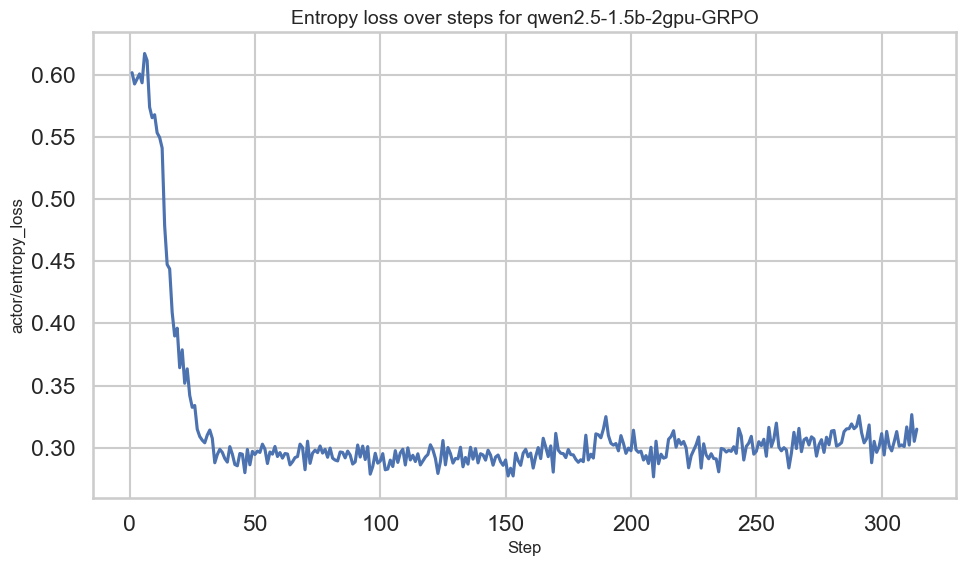

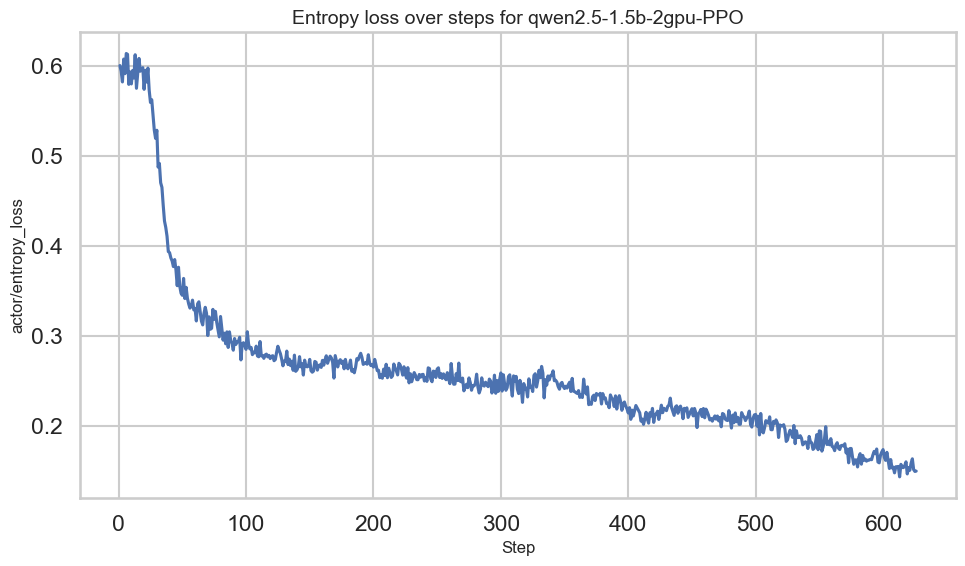

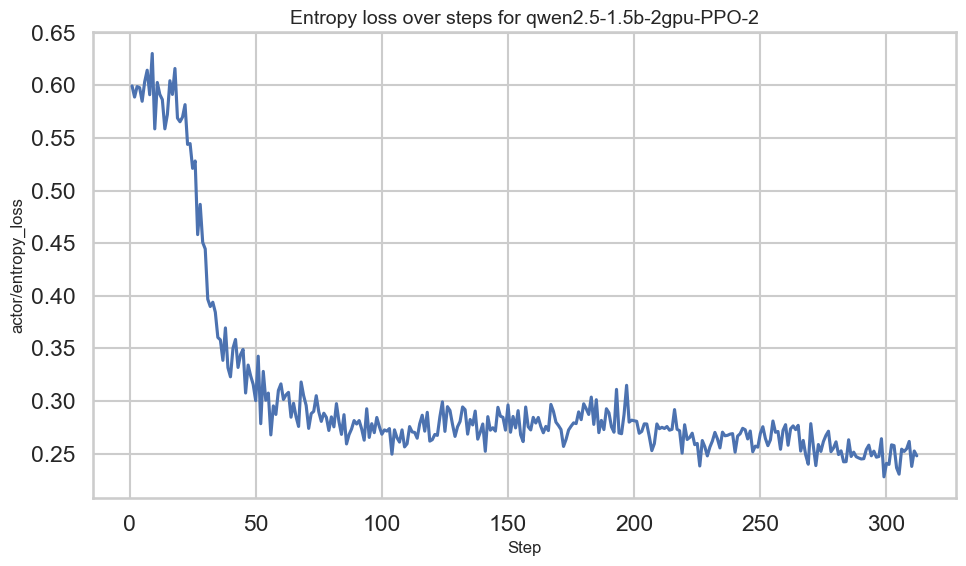

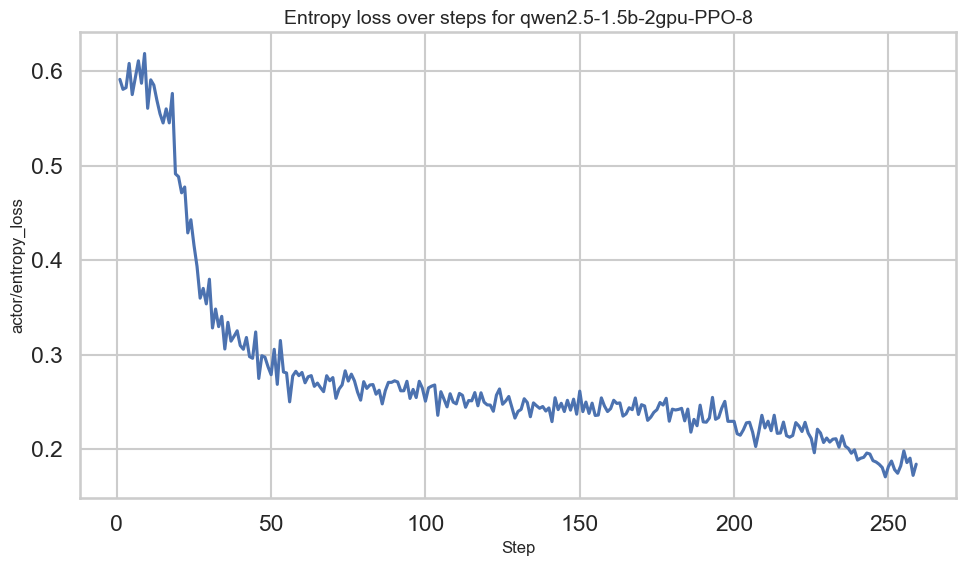

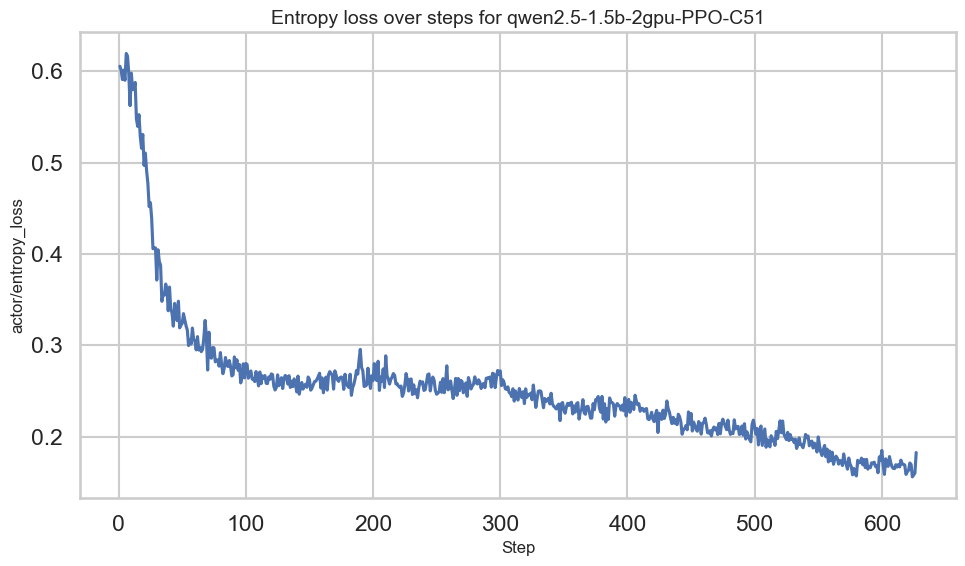

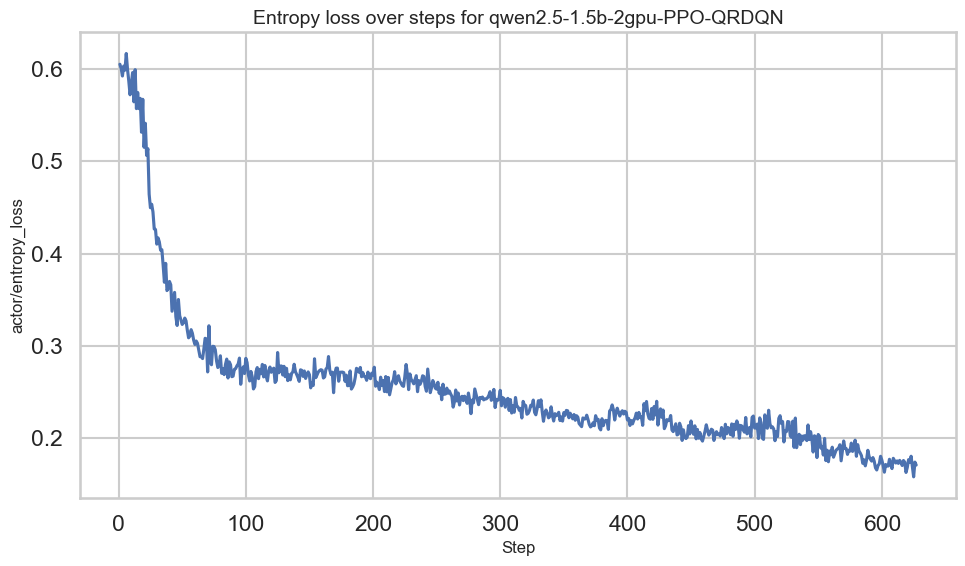

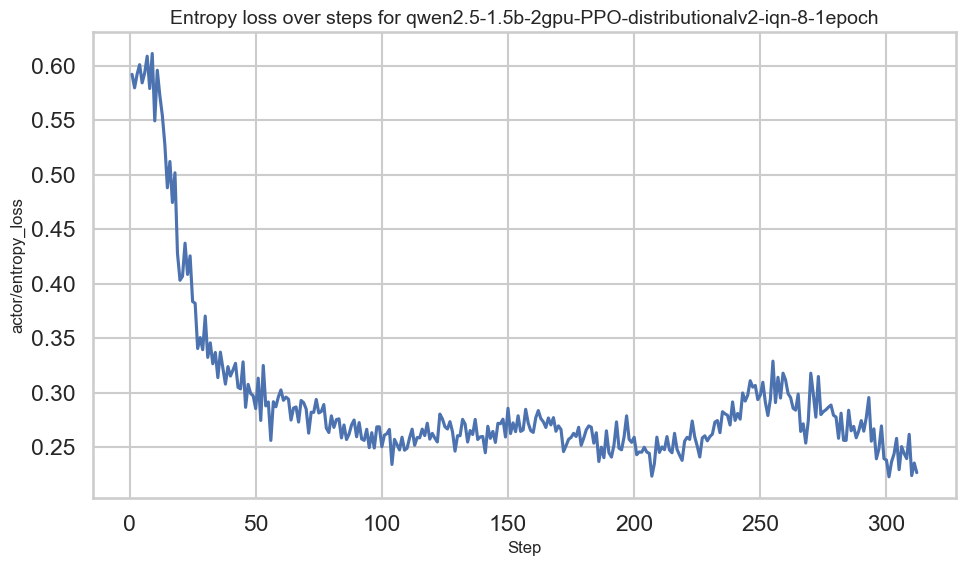

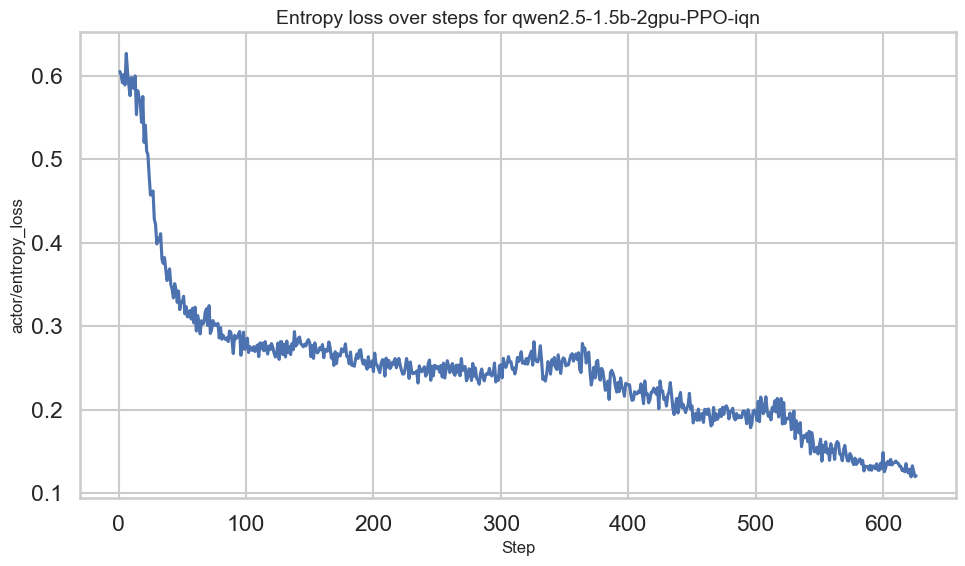

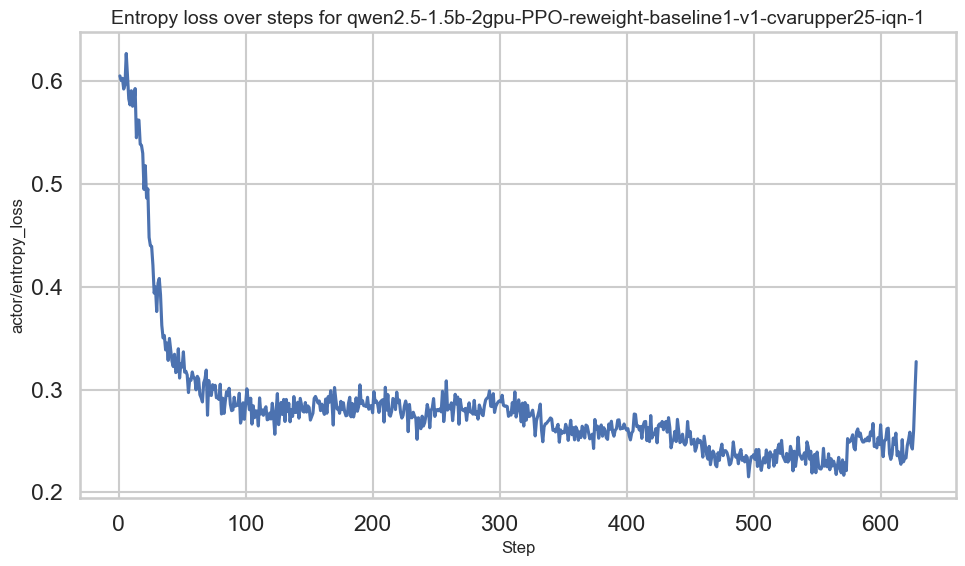

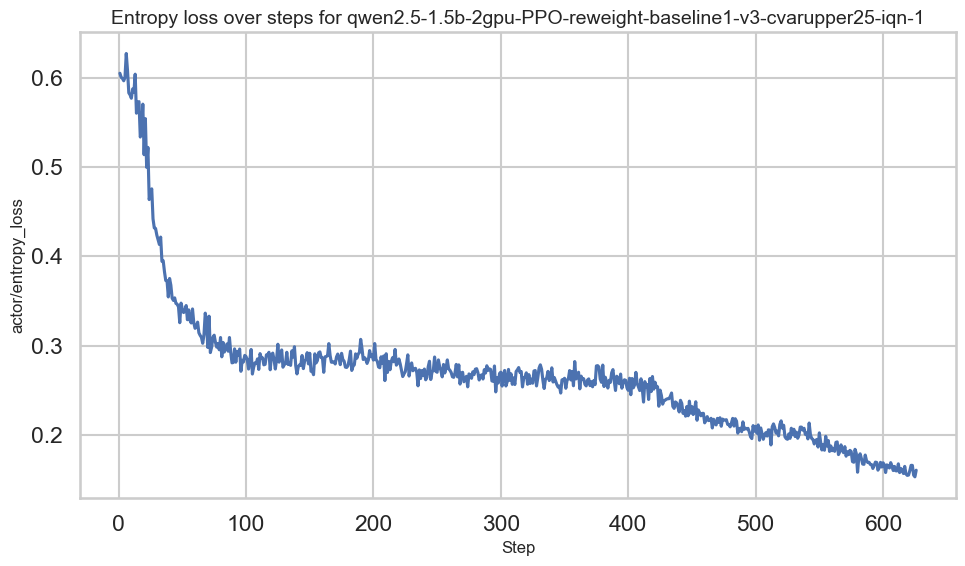

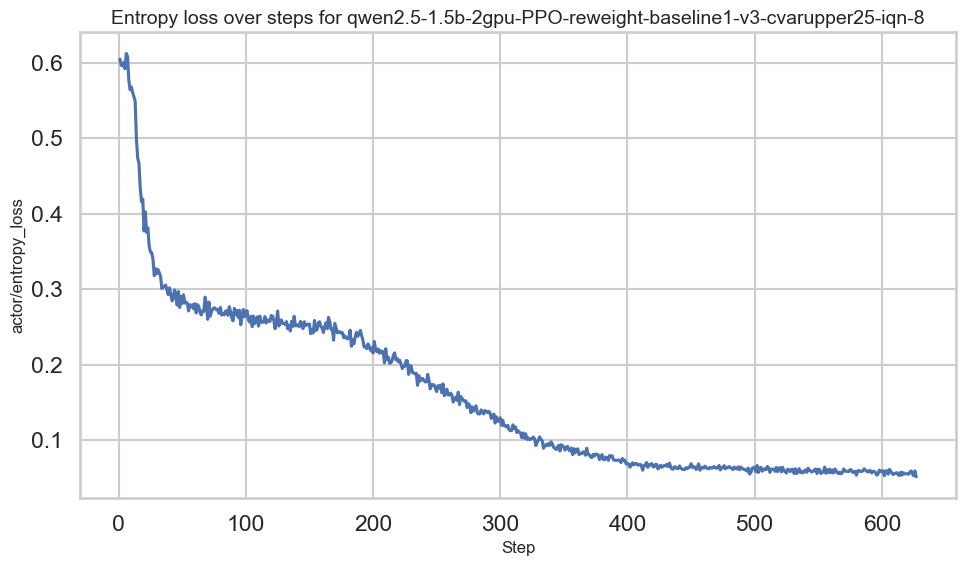

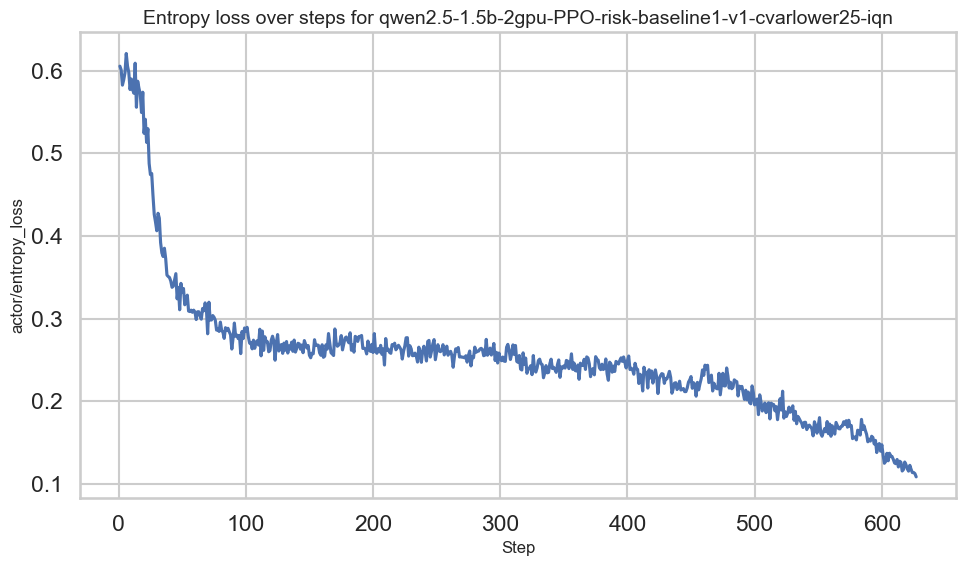

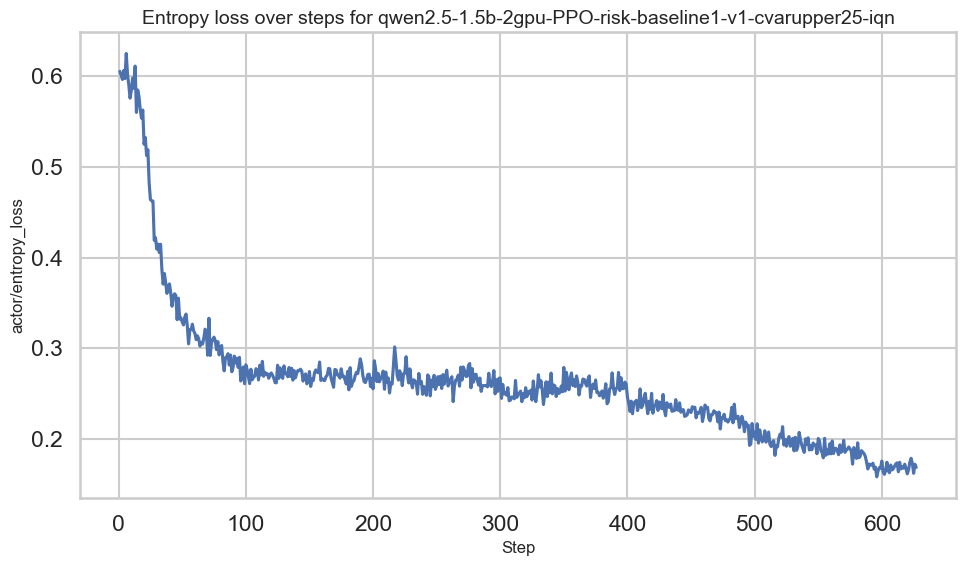

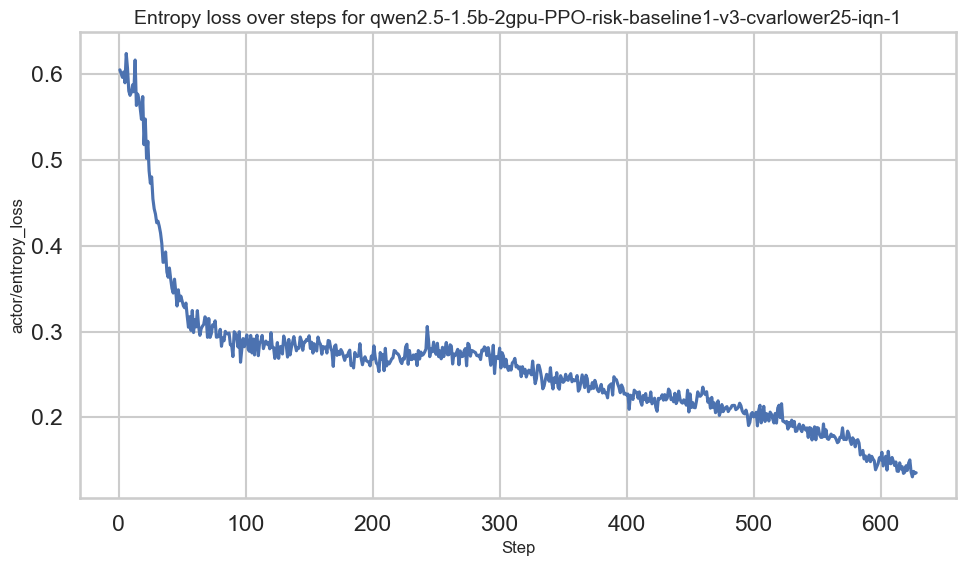

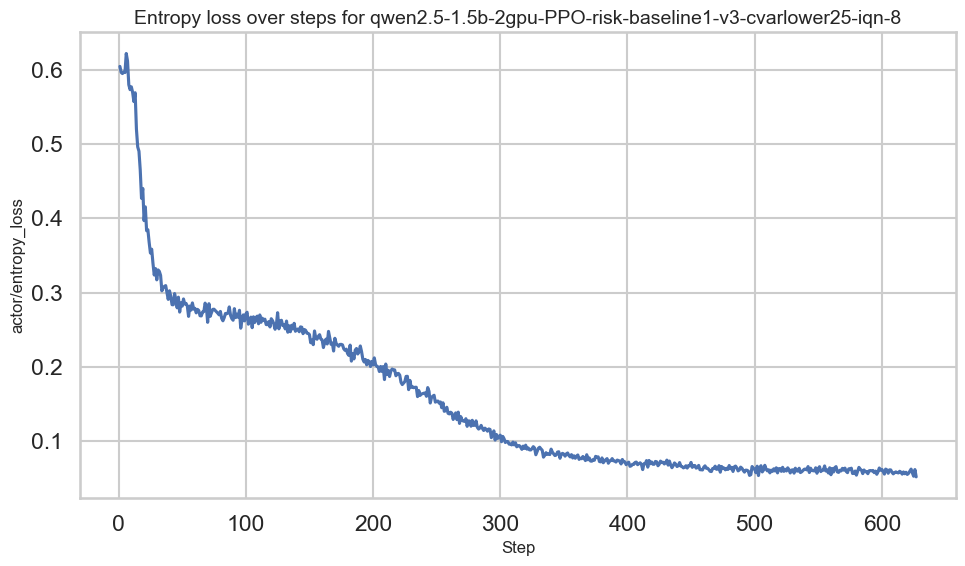

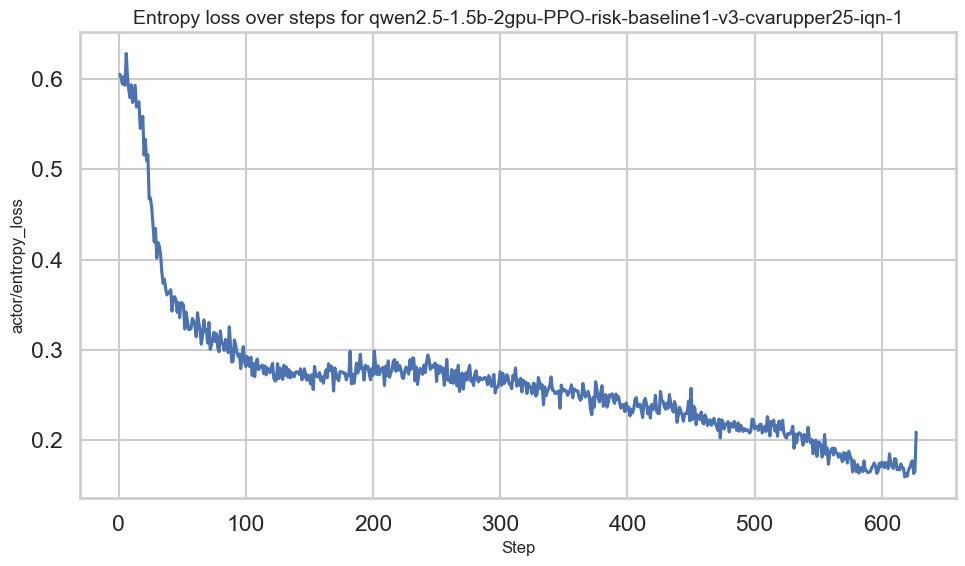

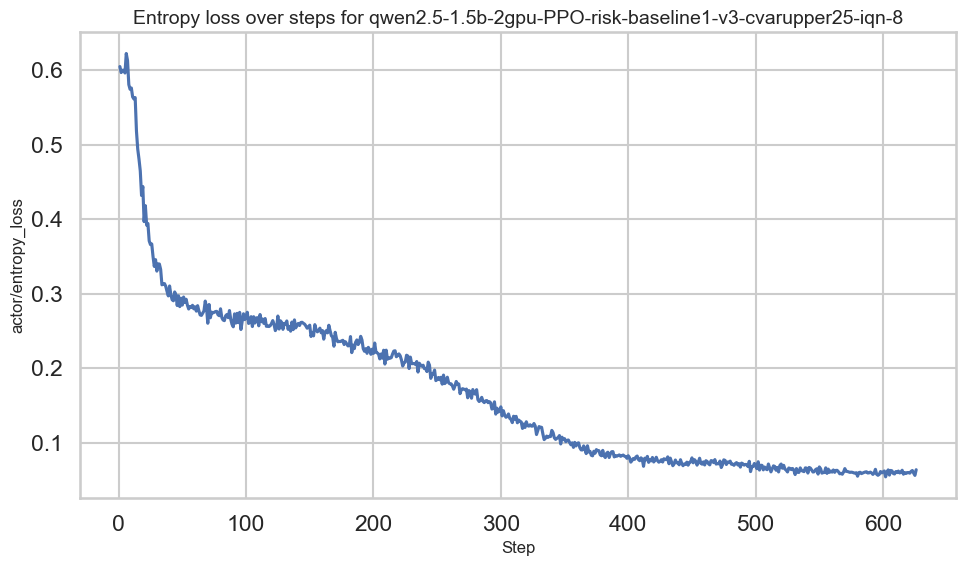

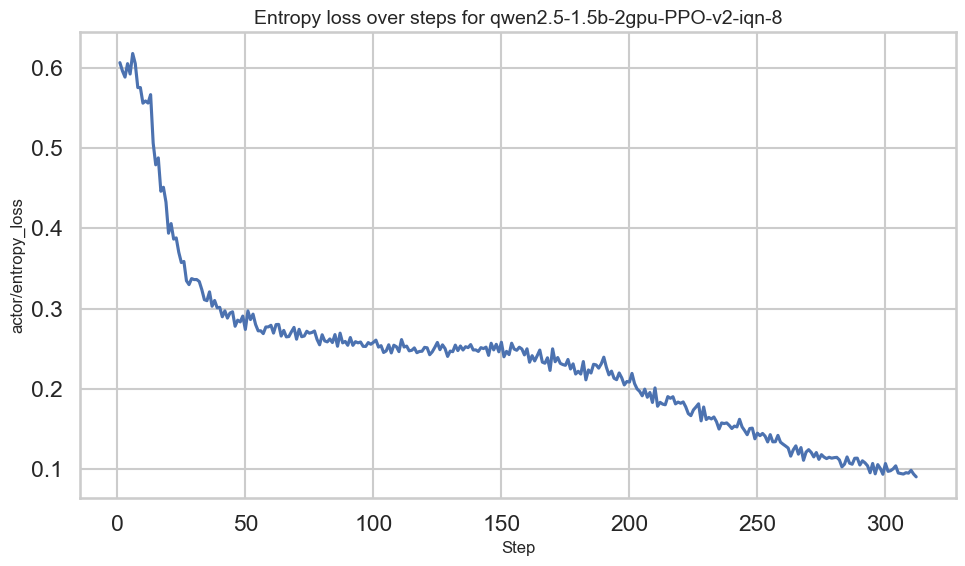

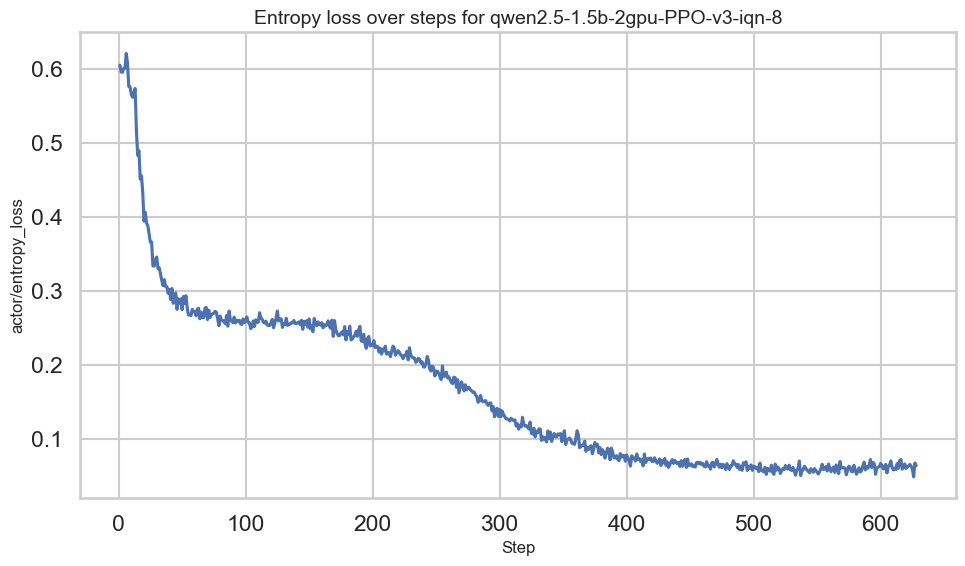

In [54]:
# Plot 1: entropy loss over steps per algorithm
for algo in sorted(ent_agg["algorithm"].unique()):
    sub = ent_agg[ent_agg["algorithm"] == algo]
    new_fig(f"Entropy loss over steps for {algo}")
    sns.lineplot(data=sub, x="Step", y="actor/entropy_loss")
    plt.tight_layout()
    plt.show()


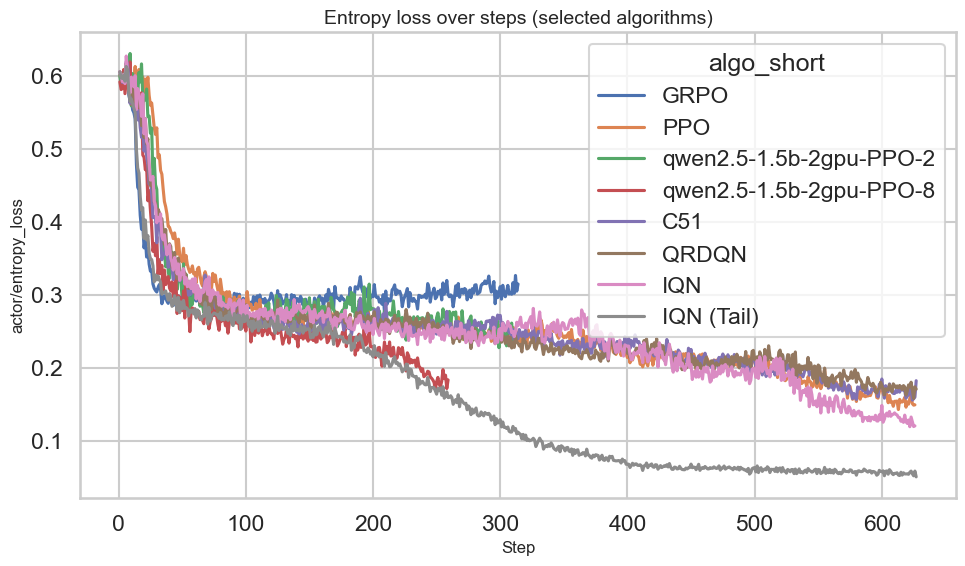

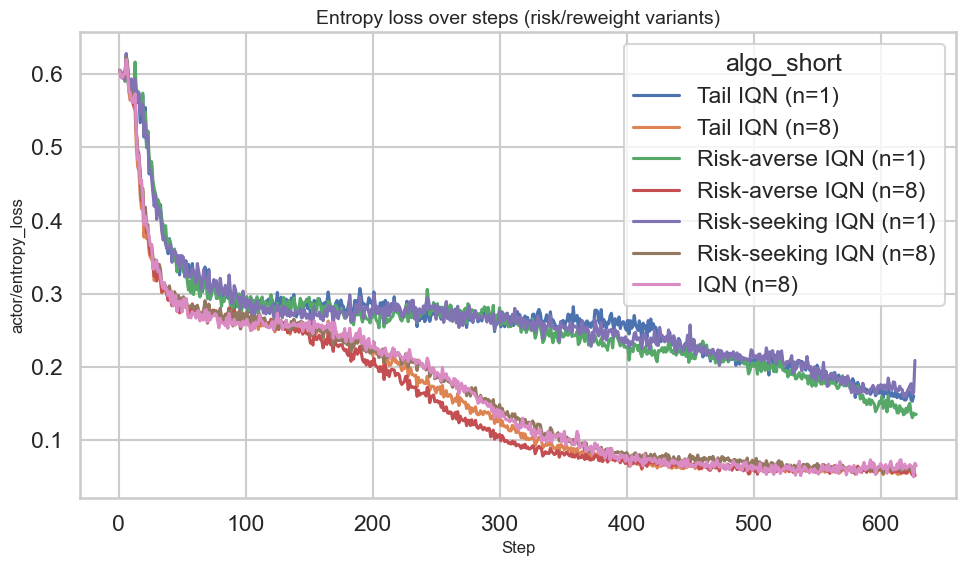

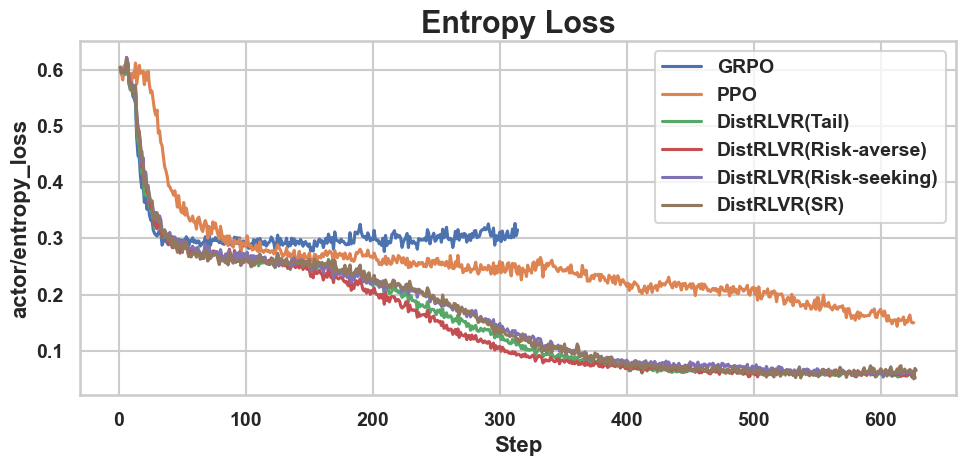

In [60]:
# Plot 1b: entropy loss over steps (selected algorithms)
keep_algos = [
    "qwen2.5-1.5b-2gpu-GRPO",
    "qwen2.5-1.5b-2gpu-PPO",
    "qwen2.5-1.5b-2gpu-PPO-2",
    "qwen2.5-1.5b-2gpu-PPO-8",
    "qwen2.5-1.5b-2gpu-PPO-C51",
    "qwen2.5-1.5b-2gpu-PPO-QRDQN",
    "qwen2.5-1.5b-2gpu-PPO-iqn",
    "qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v3-cvarupper25-iqn-8",
]

label_map = {
    "qwen2.5-1.5b-2gpu-GRPO": "GRPO",
    "qwen2.5-1.5b-2gpu-PPO": "PPO",
    "qwen2.5-1.5b-2gpu-PPO-C51": "C51",
    "qwen2.5-1.5b-2gpu-PPO-QRDQN": "QRDQN",
    "qwen2.5-1.5b-2gpu-PPO-iqn": "IQN",
    "qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v3-cvarupper25-iqn-8": "IQN (Tail)",
}

new_fig("Entropy loss over steps (selected algorithms)")
sub = ent_agg[ent_agg["algorithm"].isin(keep_algos)].copy()
sub["algo_short"] = sub["algorithm"].map(label_map).fillna(sub["algorithm"])
sns.lineplot(data=sub, x="Step", y="actor/entropy_loss", hue="algo_short")
plt.tight_layout()
plt.show()

# Plot 1c: entropy loss over steps (risk/reweight variants)
risk_algos = [
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarlower25-iqn-1",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarlower25-iqn-8",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarupper25-iqn-1",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarupper25-iqn-8",
    "qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v3-cvarupper25-iqn-1",
    "qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v3-cvarupper25-iqn-8",
    "qwen2.5-1.5b-2gpu-PPO-v3-iqn-8",
]

risk_label_map = {
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarlower25-iqn-1": "Risk-averse IQN (n=1)",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarlower25-iqn-8": "Risk-averse IQN (n=8)",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarupper25-iqn-1": "Risk-seeking IQN (n=1)",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarupper25-iqn-8": "Risk-seeking IQN (n=8)",
    "qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v3-cvarupper25-iqn-1": "Tail IQN (n=1)",
    "qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v3-cvarupper25-iqn-8": "Tail IQN (n=8)",
    "qwen2.5-1.5b-2gpu-PPO-v3-iqn-8": "IQN (n=8)",
}

new_fig("Entropy loss over steps (risk/reweight variants)")
sub = ent_agg[ent_agg["algorithm"].isin(risk_algos)].copy()
sub["algo_short"] = sub["algorithm"].map(risk_label_map).fillna(sub["algorithm"])
sns.lineplot(data=sub, x="Step", y="actor/entropy_loss", hue="algo_short")
plt.tight_layout()
plt.show()

# Plot 1d: entropy loss over steps (PPO/GRPO + n=8 variants)
combo_algos = [
    "qwen2.5-1.5b-2gpu-GRPO",
    "qwen2.5-1.5b-2gpu-PPO",
    "qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v3-cvarupper25-iqn-8",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarlower25-iqn-8",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarupper25-iqn-8",
    "qwen2.5-1.5b-2gpu-PPO-v3-iqn-8",
]

combo_label_map = {
    "qwen2.5-1.5b-2gpu-GRPO": "GRPO",
    "qwen2.5-1.5b-2gpu-PPO": "PPO",
    "qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v3-cvarupper25-iqn-8": "DistRLVR(Tail)",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarlower25-iqn-8": "DistRLVR(Risk-averse)",
    "qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarupper25-iqn-8": "DistRLVR(Risk-seeking)",
    "qwen2.5-1.5b-2gpu-PPO-v3-iqn-8": "DistRLVR(SR)",
}

new_fig("Entropy Loss")
plt.gcf().set_size_inches(10, 5)
sub = ent_agg[ent_agg["algorithm"].isin(combo_algos)].copy()
sub["algo_short"] = sub["algorithm"].map(combo_label_map).fillna(sub["algorithm"])
sns.lineplot(data=sub, x="Step", y="actor/entropy_loss", hue="algo_short")
ax = plt.gca()
plt.title("Entropy Loss", fontsize=22, fontweight="bold")
plt.xlabel("Step", fontsize=16, fontweight="bold")
plt.ylabel("actor/entropy_loss", fontsize=16, fontweight="bold")
leg = plt.legend(title=None, fontsize=14)
plt.tick_params(axis="both", labelsize=14)
for lbl in ax.get_xticklabels() + ax.get_yticklabels():
    lbl.set_fontweight("bold")
if leg is not None:
    for txt in leg.get_texts():
        txt.set_fontweight("bold")
plt.tight_layout()
plt.savefig("final_results/figs/ent.pdf", bbox_inches="tight")
plt.show()


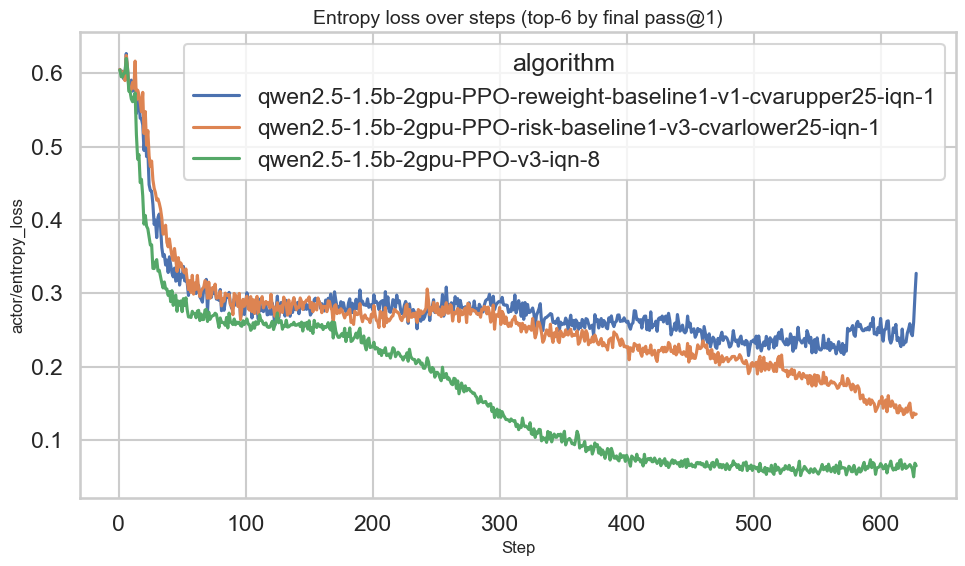

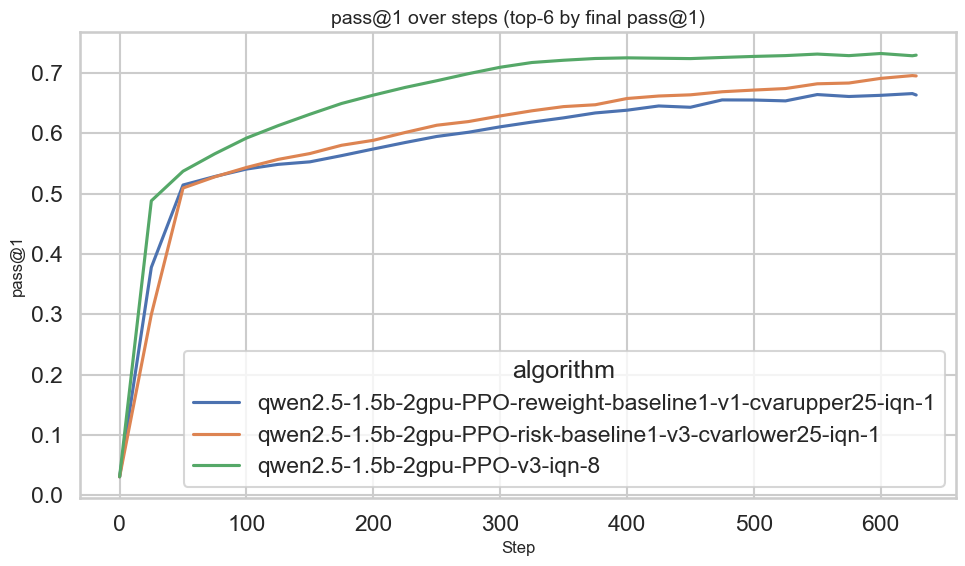

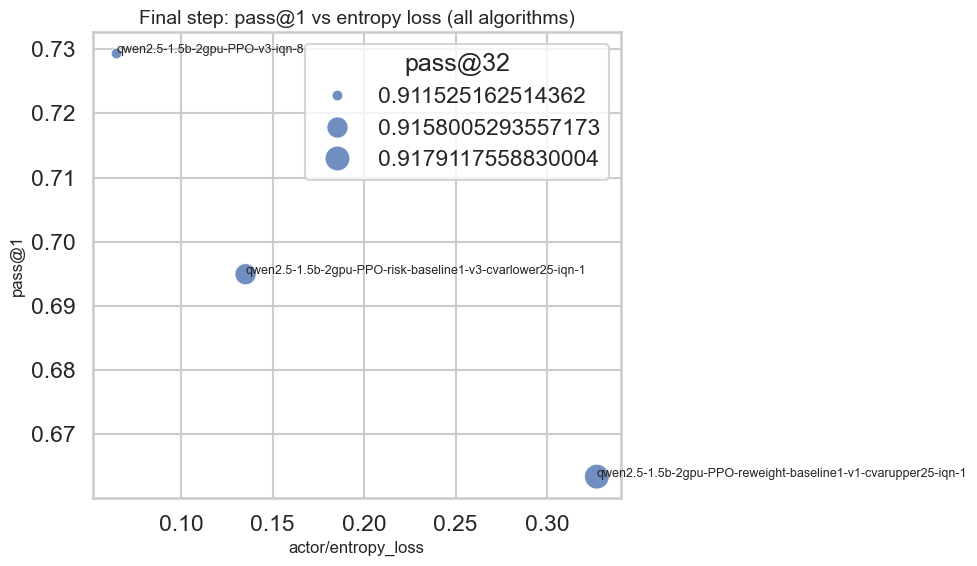

/var/folders/ls/fnbjmj5s4gb_gwcc98ln1lgm0000gn/T/ipykernel_65771/4282418563.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=corr_df, x="corr_entropy_pass1", y="algorithm", palette="viridis")


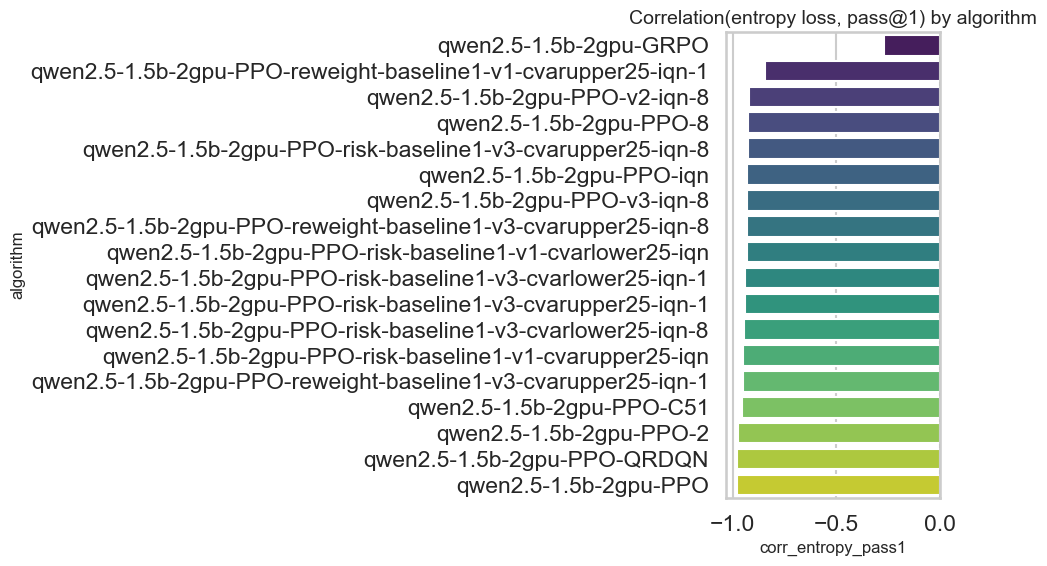

,algorithm,pass@1,pass@8,pass@32,avg@32,actor/entropy_loss
399,qwen2.5-1.5b-2gpu-PPO-v3-iqn-8,0.729349,0.865731,0.911525,0.725639,0.064787
398,qwen2.5-1.5b-2gpu-PPO-risk-baseline1-v3-cvarlo...,0.694913,0.860862,0.915801,0.696737,0.135278
397,qwen2.5-1.5b-2gpu-PPO-reweight-baseline1-v1-cv...,0.663327,0.858651,0.917912,0.667209,0.327201


In [56]:
# Comparison: top algorithms and cross-method trends
merged = pd.merge(agg, ent_agg, on=["Step", "algorithm"], how="inner")
ranking = agg[agg["Step"] == final_step].sort_values("pass@1", ascending=False)
focus_algos = ranking["algorithm"].head(6).tolist()

# Overlay entropy loss for top algorithms
new_fig("Entropy loss over steps (top-6 by final pass@1)")
sub = ent_agg[ent_agg["algorithm"].isin(focus_algos)]
sns.lineplot(data=sub, x="Step", y="actor/entropy_loss", hue="algorithm")
plt.tight_layout()
plt.show()

# Overlay pass@1 for top algorithms
new_fig("pass@1 over steps (top-6 by final pass@1)")
sub = agg[agg["algorithm"].isin(focus_algos)]
sns.lineplot(data=sub, x="Step", y="pass@1", hue="algorithm")
plt.tight_layout()
plt.show()

# Final-step scatter across algorithms
final_merge = merged[merged["Step"] == final_step]
new_fig("Final step: pass@1 vs entropy loss (all algorithms)")
sns.scatterplot(
    data=final_merge,
    x="actor/entropy_loss",
    y="pass@1",
    size="pass@32",
    sizes=(60, 320),
    alpha=0.8,
)
for _, row in final_merge[final_merge["algorithm"].isin(focus_algos)].iterrows():
    plt.text(row["actor/entropy_loss"], row["pass@1"], row["algorithm"], fontsize=9)
plt.tight_layout()
plt.show()

# Per-algorithm correlation between entropy loss and pass@1 over steps
corr_rows = []
for algo in merged["algorithm"].unique():
    sub = merged[merged["algorithm"] == algo][["actor/entropy_loss", "pass@1"]].dropna()
    if len(sub) >= 3:
        corr = sub.corr().iloc[0, 1]
        corr_rows.append({"algorithm": algo, "corr_entropy_pass1": corr})

corr_df = pd.DataFrame(corr_rows).sort_values("corr_entropy_pass1", ascending=False)
new_fig("Correlation(entropy loss, pass@1) by algorithm")
sns.barplot(data=corr_df, x="corr_entropy_pass1", y="algorithm", palette="viridis")
plt.axvline(0, color="black", linewidth=1)
plt.tight_layout()
plt.show()

# Summary table for top algorithms at final step
summary = final_merge[final_merge["algorithm"].isin(focus_algos)][
    ["algorithm", "pass@1", "pass@8", "pass@32", "avg@32", "actor/entropy_loss"]
].sort_values("pass@1", ascending=False)
try:
    from IPython.display import display
    display(summary)
except Exception:
    print(summary.to_string(index=False))


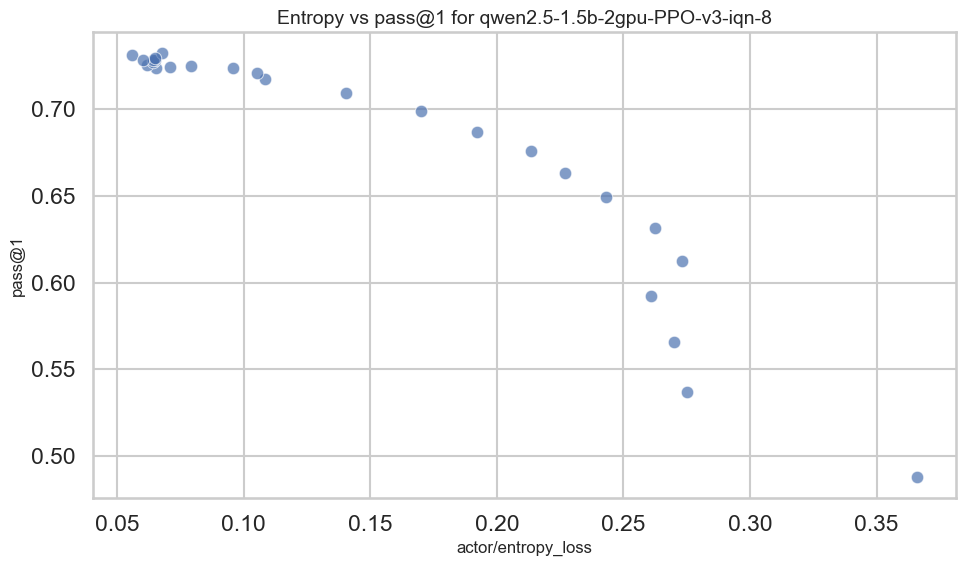

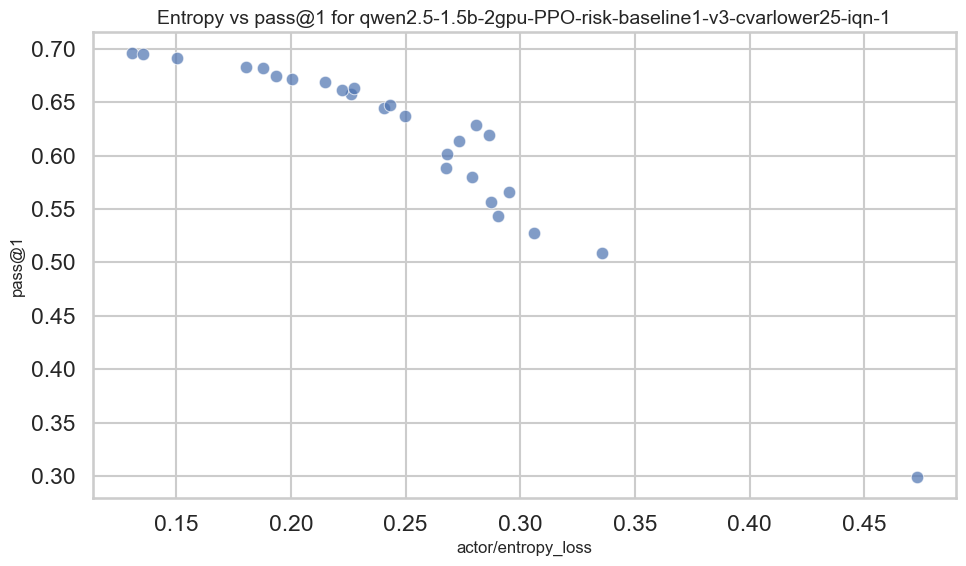

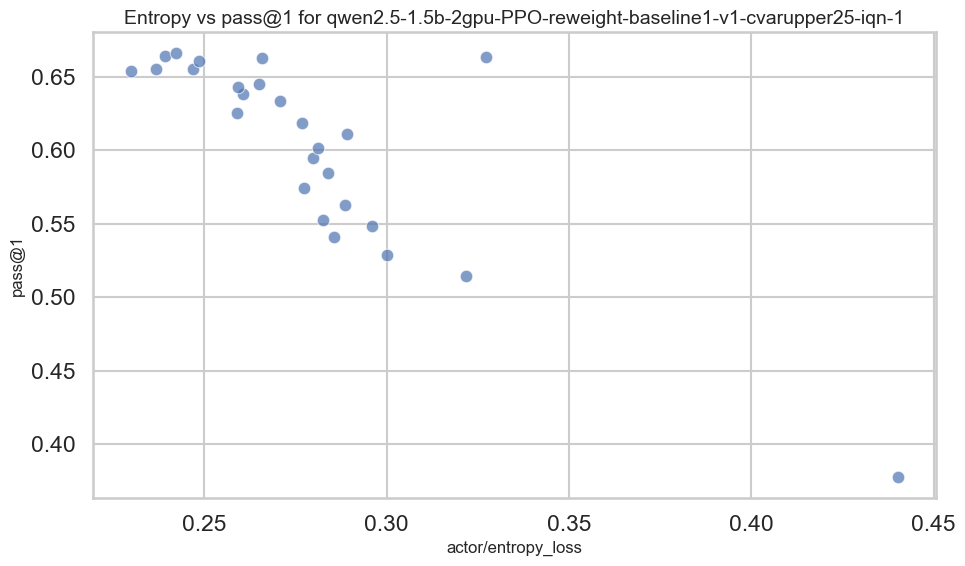

In [57]:
# Plot 2: correlation between entropy loss and pass@1 (top-6 algorithms)
merged = pd.merge(agg, ent_agg, on=["Step", "algorithm"], how="inner")
ranking = agg[agg["Step"] == final_step].sort_values("pass@1", ascending=False)
focus_algos = ranking["algorithm"].head(6).tolist()

for algo in focus_algos:
    sub = merged[merged["algorithm"] == algo]
    new_fig(f"Entropy vs pass@1 for {algo}")
    sns.scatterplot(data=sub, x="actor/entropy_loss", y="pass@1", alpha=0.7)
    plt.tight_layout()
    plt.show()


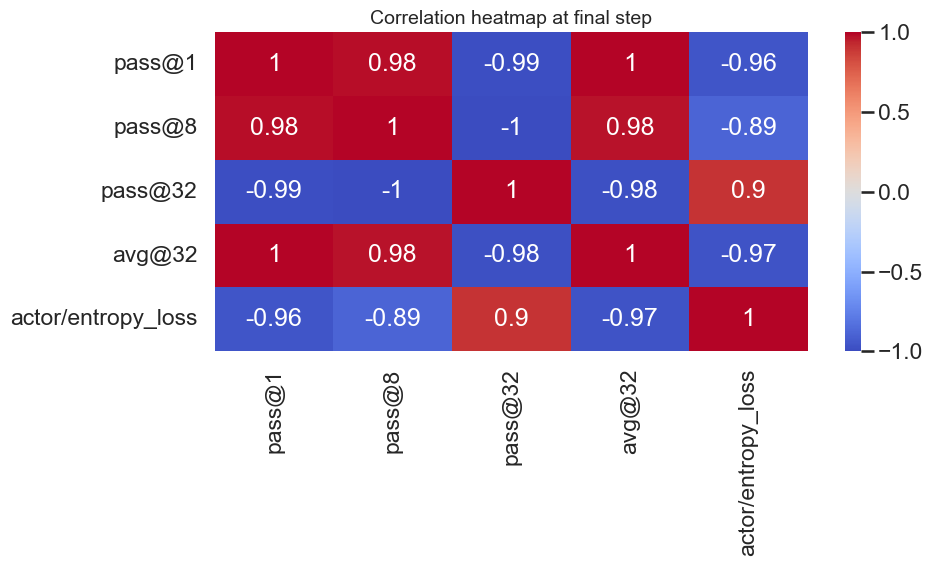

Generated 30 figures


In [58]:
# Plot 3: cross-algorithm correlation heatmap at final step
final_merge = merged[merged["Step"] == final_step]
metrics_corr = final_merge[["pass@1", "pass@8", "pass@32", "avg@32", "actor/entropy_loss"]].corr()
new_fig("Correlation heatmap at final step")
sns.heatmap(metrics_corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.tight_layout()
plt.show()

print(f"Generated {PLOT_COUNTER} figures")
